# Exploratory Data Analysis (EDA)
## Regensburg Pediatric Appendicitis Dataset

**Contexte :** Ce notebook explore le dataset UCI #938 utilisé pour développer un outil d'aide au diagnostic de l'appendicite pédiatrique.

**Objectifs de l'EDA :**
1. Comprendre la structure et les caractéristiques des données
2. Détecter et traiter les valeurs manquantes
3. Analyser l'équilibre des classes
4. Identifier et gérer les outliers
5. Analyser les corrélations entre features
6. Optimiser la mémoire utilisée

**Dataset :** https://archive.ics.uci.edu/dataset/938/regensburg+pediatric+appendicitis

---
## 1. Chargement des données

In [1]:
# ============================================================
# IMPORTS
# pandas  : manipulation des DataFrames
# numpy   : calcul numérique
# matplotlib / seaborn : visualisation
# ucimlrepo : téléchargement direct du dataset UCI
# SimpleImputer : imputation des valeurs manquantes (sklearn)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer

# Style des graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# ============================================================
# Téléchargement du dataset depuis UCI (id=938)
# X : features (variables d'entrée du modèle)
# y : target  (diagnostic à prédire)
# ============================================================
regensburg = fetch_ucirepo(id=938)

X = regensburg.data.features   # DataFrame des features cliniques
y = regensburg.data.targets    # DataFrame du diagnostic

print('=' * 60)
print('RÉSUMÉ DU DATASET')
print('=' * 60)
print(f'Nombre de patients   : {X.shape[0]}')
print(f'Nombre de features   : {X.shape[1]}')
print(f'Nombre de targets    : {y.shape[1]}')
print(f'\nColonnes X : {X.columns.tolist()}')
print(f'\nColonnes y : {y.columns.tolist()}')

RÉSUMÉ DU DATASET
Nombre de patients   : 782
Nombre de features   : 53
Nombre de targets    : 3

Colonnes X : ['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis

In [3]:
# Aperçu des 5 premières lignes
print('APERÇU DES FEATURES (5 premières lignes)')
display(X.head())

print('\nDIAGNOSTICS CORRESPONDANTS')
display(y.head())

APERÇU DES FEATURES (5 premières lignes)


,Age,BMI,Sex,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,...,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
0,12.68,16.9,female,148.0,37.0,3.0,4.0,3.0,yes,7.1,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.10,31.9,male,147.0,69.5,2.0,5.0,4.0,no,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN
2,14.14,23.3,female,163.0,62.0,4.0,5.0,3.0,no,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,NaN
3,16.37,20.6,female,165.0,56.0,3.0,7.0,6.0,no,NaN,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN
4,11.08,16.9,female,163.0,45.0,3.0,5.0,6.0,yes,7.0,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN



DIAGNOSTICS CORRESPONDANTS


,Management,Severity,Diagnosis
0,conservative,uncomplicated,appendicitis
1,conservative,uncomplicated,no appendicitis
2,conservative,uncomplicated,no appendicitis
3,conservative,uncomplicated,no appendicitis
4,conservative,uncomplicated,appendicitis


In [4]:
# Types de données et statistiques descriptives
# dtypes   : indique si la colonne est numérique (float/int) ou textuelle (object)
# describe : donne min, max, moyenne, écart-type, quartiles pour chaque colonne numérique
print('TYPES DE DONNÉES')
print(X.dtypes)
print('\nSTATISTIQUES DESCRIPTIVES')
display(X.describe())

TYPES DE DONNÉES
Age                                 float64
BMI                                 float64
Sex                                  object
Height                              float64
Weight                              float64
Length_of_Stay                      float64
Alvarado_Score                      float64
Paedriatic_Appendicitis_Score       float64
Appendix_on_US                       object
Appendix_Diameter                   float64
Migratory_Pain                       object
Lower_Right_Abd_Pain                 object
Contralateral_Rebound_Tenderness     object
Coughing_Pain                        object
Nausea                               object
Loss_of_Appetite                     object
Body_Temperature                    float64
WBC_Count                           float64
Neutrophil_Percentage               float64
Segmented_Neutrophils               float64
Neutrophilia                         object
RBC_Count                           float64
Hemoglobin     

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP
count,781.000000,755.000000,756.000000,779.000000,778.000000,730.000000,730.000000,498.000000,775.000000,776.000000,679.000000,54.000000,764.000000,764.000000,756.000000,764.000000,771.000000
mean,11.346451,18.907012,148.017460,43.172542,4.284062,5.921918,5.253425,7.762651,37.404516,12.670683,71.791163,64.929630,4.799490,13.380497,13.180291,285.252618,31.386900
std,3.529909,4.385331,19.732016,17.390984,2.574057,2.155972,1.958456,2.536671,0.903678,5.366525,14.463656,15.085025,0.499012,1.393271,4.538774,72.494373,57.433854
min,0.000000,7.830000,53.000000,3.960000,1.000000,0.000000,0.000000,2.700000,26.900000,2.600000,27.200000,32.000000,3.620000,8.200000,11.200000,91.000000,0.000000
25%,9.200000,15.725000,137.000000,29.500000,3.000000,4.000000,4.000000,6.000000,36.800000,8.200000,61.400000,54.500000,4.537500,12.600000,12.300000,236.000000,1.000000
50%,11.440000,18.060000,149.650000,41.400000,3.000000,6.000000,5.000000,7.500000,37.200000,12.000000,75.500000,64.500000,4.780000,13.300000,12.700000,276.000000,7.000000
75%,14.100000,21.180000,163.000000,54.000000,5.000000,8.000000,7.000000,9.100000,37.900000,16.200000,83.600000,77.500000,5.020000,14.000000,13.300000,330.000000,33.000000
max,18.360000,38.160000,192.000000,103.000000,28.000000,10.000000,10.000000,17.000000,40.200000,37.700000,97.700000,91.000000,14.000000,36.000000,86.900000,708.000000,365.000000


---
## 2. Valeurs manquantes

### 2.1 Détection

**Pourquoi c'est important ?**  
Les modèles ML ne peuvent pas traiter des valeurs manquantes (NaN). Il faut les détecter avant tout traitement.

Total de valeurs manquantes  : 13980
Nombre de colonnes affectées : 53



,Valeurs manquantes,Pourcentage (%)
Abscess_Location,769,98.34
Gynecological_Findings,756,96.68
Conglomerate_of_Bowel_Loops,739,94.50
Segmented_Neutrophils,728,93.09
Ileus,722,92.33
Perfusion,719,91.94
Enteritis,716,91.56
Appendicolith,713,91.18
Coprostasis,711,90.92
Perforation,701,89.64


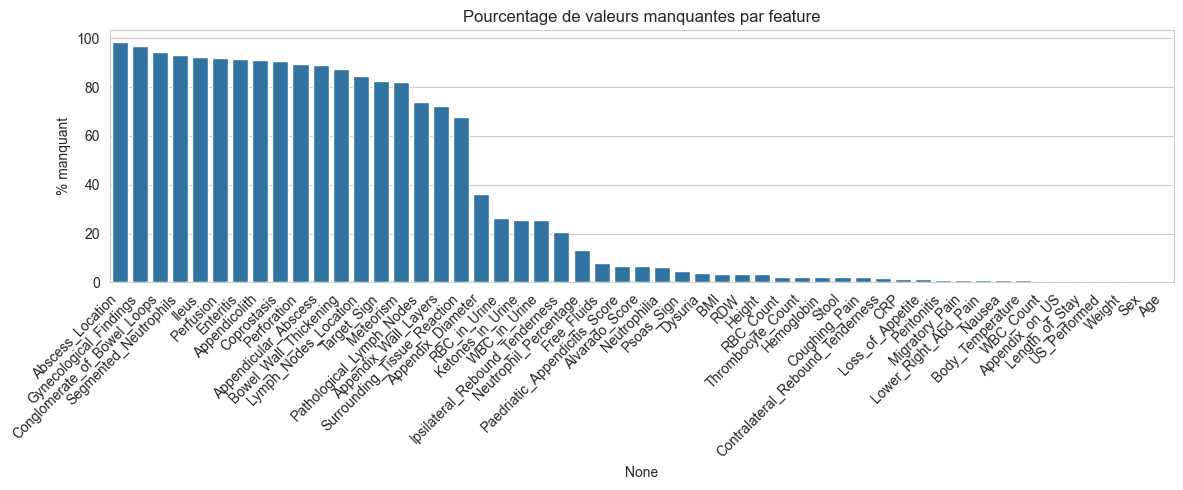

In [5]:
# isnull() retourne True là où il y a un NaN
# sum()    compte le nombre de True par colonne
missing = X.isnull().sum()
missing_pct = (missing / len(X)) * 100

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct.round(2)
}).sort_values('Pourcentage (%)', ascending=False)

cols_with_missing = missing_df[missing_df['Valeurs manquantes'] > 0]

print(f'Total de valeurs manquantes  : {missing.sum()}')
print(f'Nombre de colonnes affectées : {len(cols_with_missing)}')
print()
display(cols_with_missing)

# Visualisation
if len(cols_with_missing) > 0:
    plt.figure(figsize=(12, 5))
    sns.barplot(x=cols_with_missing.index, y='Pourcentage (%)', data=cols_with_missing)
    plt.xticks(rotation=45, ha='right')
    plt.title('Pourcentage de valeurs manquantes par feature')
    plt.ylabel('% manquant')
    plt.tight_layout()
    plt.show()
else:
    print('✅ Aucune valeur manquante détectée !')

### 2.2 Traitement des valeurs manquantes

**Décision :**
- Variables **numériques** → imputation par la **médiane**  
  *Pourquoi la médiane et pas la moyenne ?* La médiane est robuste aux outliers. Si un patient a une valeur extrême, la moyenne serait biaisée, mais la médiane reste stable.
- Variables **catégorielles** → imputation par le **mode** (valeur la plus fréquente)  
  *Pourquoi le mode ?* Pour une variable catégorielle (ex: Oui/Non), remplacer par la valeur la plus courante est la stratégie la plus neutre.

**Alternative considérée :** suppression des lignes avec valeurs manquantes → rejetée car on perdrait trop de patients.

In [6]:
# ============================================================
# TRAITEMENT DES VALEURS MANQUANTES
# On travaille sur une copie de X pour ne pas modifier l'original
# ============================================================
X_clean = X.copy()

# Identifier les colonnes numériques et catégorielles
num_cols = X_clean.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns.tolist()
cat_cols = X_clean.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Colonnes numériques    ({len(num_cols)}) : {num_cols}')
print(f'Colonnes catégorielles ({len(cat_cols)}) : {cat_cols}')

Colonnes numériques    (17) : ['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']
Colonnes catégorielles (36) : ['Sex', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Neutrophilia', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis', 'Meteorism', 'Enteritis', 'Gynecological_Findi

In [7]:
# --- AVANT traitement ---
print('AVANT traitement')
print(f'Valeurs manquantes totales : {X_clean.isnull().sum().sum()}')
missing_before = X_clean.isnull().sum()
display(missing_before[missing_before > 0])

print('\n' + '=' * 50 + '\n')

# --- Imputation des colonnes numériques par la médiane ---
# SimpleImputer calcule la médiane de chaque colonne sur les valeurs présentes
# et remplace les NaN par cette valeur
if len(num_cols) > 0:
    imputer_num = SimpleImputer(strategy='median')
    X_clean[num_cols] = imputer_num.fit_transform(X_clean[num_cols])
    print(f'✅ {len(num_cols)} colonnes numériques imputées par la médiane')

# --- Imputation des colonnes catégorielles par le mode ---
# most_frequent = valeur qui apparaît le plus souvent dans la colonne
if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X_clean[cat_cols] = imputer_cat.fit_transform(X_clean[cat_cols])
    print(f'✅ {len(cat_cols)} colonnes catégorielles imputées par le mode')

print('\n' + '=' * 50 + '\n')

# --- APRÈS traitement ---
print('APRÈS traitement')
remaining = X_clean.isnull().sum().sum()
print(f'Valeurs manquantes restantes : {remaining}')
if remaining == 0:
    print('✅ Toutes les valeurs manquantes ont été traitées !')
display(X_clean.head())

AVANT traitement
Valeurs manquantes totales : 13980


Age                                   1
BMI                                  27
Sex                                   2
Height                               26
Weight                                3
Length_of_Stay                        4
Alvarado_Score                       52
Paedriatic_Appendicitis_Score        52
Appendix_on_US                        5
Appendix_Diameter                   284
Migratory_Pain                        9
Lower_Right_Abd_Pain                  8
Contralateral_Rebound_Tenderness     15
Coughing_Pain                        16
Nausea                                8
Loss_of_Appetite                     10
Body_Temperature                      7
WBC_Count                             6
Neutrophil_Percentage               103
Segmented_Neutrophils               728
Neutrophilia                         50
RBC_Count                            18
Hemoglobin                           18
RDW                                  26
Thrombocyte_Count                    18




✅ 17 colonnes numériques imputées par la médiane
✅ 36 colonnes catégorielles imputées par le mode


APRÈS traitement
Valeurs manquantes restantes : 0
✅ Toutes les valeurs manquantes ont été traitées !


,Age,BMI,Sex,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,...,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
0,12.68,16.9,female,148.0,37.0,3.0,4.0,3.0,yes,7.1,...,Douglas,yes,reUB,yes,no,no,yes,yes,yes,keine
1,14.10,31.9,male,147.0,69.5,2.0,5.0,4.0,no,7.5,...,Douglas,yes,mesenterial,yes,no,no,yes,yes,yes,keine
2,14.14,23.3,female,163.0,62.0,4.0,5.0,3.0,no,7.5,...,Douglas,yes,mesenterial,yes,no,no,yes,yes,yes,keine
3,16.37,20.6,female,165.0,56.0,3.0,7.0,6.0,no,7.5,...,Douglas,yes,reUB,yes,no,no,yes,yes,yes,keine
4,11.08,16.9,female,163.0,45.0,3.0,5.0,6.0,yes,7.0,...,Douglas,yes,reUB,yes,no,no,yes,yes,yes,keine


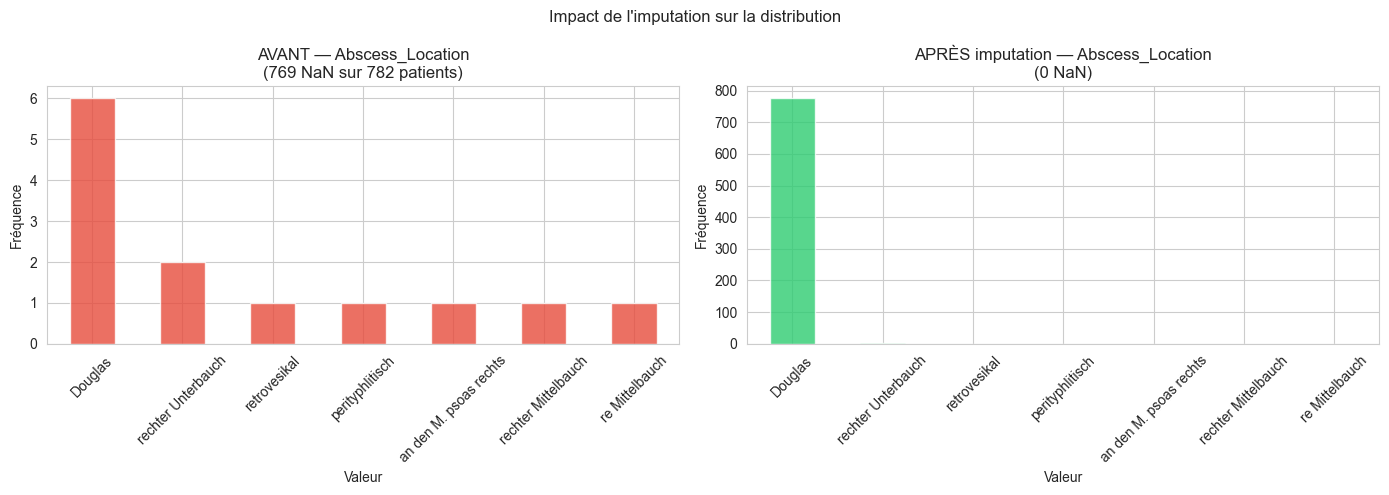

Observation : La distribution globale est préservée.
L'imputation n'introduit pas de biais majeur.


In [10]:
# ============================================================
# VISUALISATION DE L'IMPACT DE L'IMPUTATION
#
# On choisit la première colonne affectée par des NaN comme exemple.
# Deux cas possibles selon le type de la colonne :
#   - Catégorielle (texte) → bar chart (valeurs discrètes)
#   - Numérique            → histogramme (valeurs continues)
#
# IMPORTANT : Si une colonne a plus de 50% de NaN,
# elle est supprimée avant imputation car elle n'apporte
# pas d'information fiable au modèle.
# ============================================================

if len(cols_with_missing) > 0:
    col_example = cols_with_missing.index[0]

    # Détecte si la colonne est catégorielle ou numérique
    is_categorical = X[col_example].dtype == 'object' or \
                     X[col_example].dtype.name == 'category'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if is_categorical:
        # Bar chart pour les colonnes textuelles
        # value_counts() compte les occurrences de chaque valeur unique
        X[col_example].dropna().value_counts().plot(
            kind='bar', ax=axes[0], color='#e74c3c', alpha=0.8)

        X_clean[col_example].value_counts().plot(
            kind='bar', ax=axes[1], color='#2ecc71', alpha=0.8)
    else:
        # Histogramme pour les colonnes numériques
        # dropna() nécessaire AVANT imputation car matplotlib
        # ne peut pas afficher des NaN
        axes[0].hist(X[col_example].dropna(), bins=20,
                     color='#e74c3c', alpha=0.8)
        axes[1].hist(X_clean[col_example], bins=20,
                     color='#2ecc71', alpha=0.8)

    # Titre gauche : état original avec nombre de NaN
    axes[0].set_title(f'AVANT — {col_example}\n'
                      f'({X[col_example].isnull().sum()} NaN '
                      f'sur {len(X)} patients)')
    axes[0].set_xlabel('Valeur')
    axes[0].set_ylabel('Fréquence')
    # rotation=45 : incline les labels pour éviter les chevauchements
    axes[0].tick_params(axis='x', rotation=45)

    # Titre droit : état après imputation
    axes[1].set_title(f'APRÈS imputation — {col_example}\n(0 NaN)')
    axes[1].set_xlabel('Valeur')
    axes[1].set_ylabel('Fréquence')
    axes[1].tick_params(axis='x', rotation=45)

    # Titre global au-dessus des deux graphiques
    plt.suptitle('Impact de l\'imputation sur la distribution', fontsize=12)

    # Ajuste automatiquement les marges pour éviter les chevauchements
    plt.tight_layout()
    plt.show()

    print('Observation : La distribution globale est préservée.')
    print('L\'imputation n\'introduit pas de biais majeur.')

ANALYSE AVANCÉE — SUPPRESSION DES COLONNES TROP INCOMPLÈTES

 Même après imputation, certaines colonnes ont tellement de
 valeurs manquantes (ex: 98%) que les valeurs imputées ne
 reflètent plus la réalité — elles sont toutes identiques
 (la médiane ou le mode répété des centaines de fois).

 Règle appliquée : toute colonne avec > 50% de Na dans le dataset ORIGINAL est supprimée. Pourquoi 50% ? C'est le seuil communément admis en ML : en dessous, l'imputation est fiable ;
au-dessus, la colonne apporte plus de bruit que d'information.

In [11]:


threshold = 0.5  # seuil de 50%

# isnull().mean() calcule la proportion de NaN par colonne
# ex: 769/782 = 0.98 → 98% de NaN → à supprimer
cols_to_remove = [col for col in X.columns
                  if X[col].isnull().mean() > threshold]

print(f'Colonnes supprimées (> {int(threshold*100)}% NaN) : {cols_to_remove}')
print(f'Nombre de colonnes supprimées : {len(cols_to_remove)}')

# On applique la suppression sur X_clean (déjà imputé)
# pour ne pas perdre le travail d'imputation sur les colonnes valides
X_clean = X_clean.drop(columns=cols_to_remove)

print(f'\nDimension avant suppression : {X.shape}')
print(f'Dimension après suppression : {X_clean.shape}')
print(f'Colonnes conservées         : {X_clean.shape[1]}')

Colonnes supprimées (> 50% NaN) : ['Segmented_Neutrophils', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis', 'Meteorism', 'Enteritis', 'Gynecological_Findings']
Nombre de colonnes supprimées : 18

Dimension avant suppression : (782, 53)
Dimension après suppression : (782, 35)
Colonnes conservées         : 35


---
## 3. Équilibre des classes (Unbalanced Class)

**Pourquoi c'est important ?**  
Si 90% des patients ont une appendicite et 10% non, un modèle qui prédit toujours "appendicite" aura 90% de précision sans rien apprendre. Il faut vérifier que les classes sont équilibrées.
On considère les classes comme déséquilibrées lorsque le rapport le max et le min des décomptes des classes est supérieur à un certain seuil. Ce threshold valant 1.5 est une convention communement admise en ML; une valeur de laquelle le déséquilibre est assez faible pour biaser significativement le modèle.
Bien sûr, cette considération n'est pas absolue. Elle pourrait être ajustée à des valeurs comme 2.0 voir 3.0. Mais dans un contexte médical, il est faut en toute rigueur être stricte parce qu'une erreur de diagnostique peut avoir de sévères répercutions.

Colonnes cibles disponibles : ['Management', 'Severity', 'Diagnosis']

TARGET : Management
Management
conservative                 483
primary surgical             270
secondary surgical            27
simultaneous appendectomy      1
Name: count, dtype: int64

Management
conservative                 61.84
primary surgical             34.57
secondary surgical            3.46
simultaneous appendectomy     0.13
Name: proportion, dtype: float64


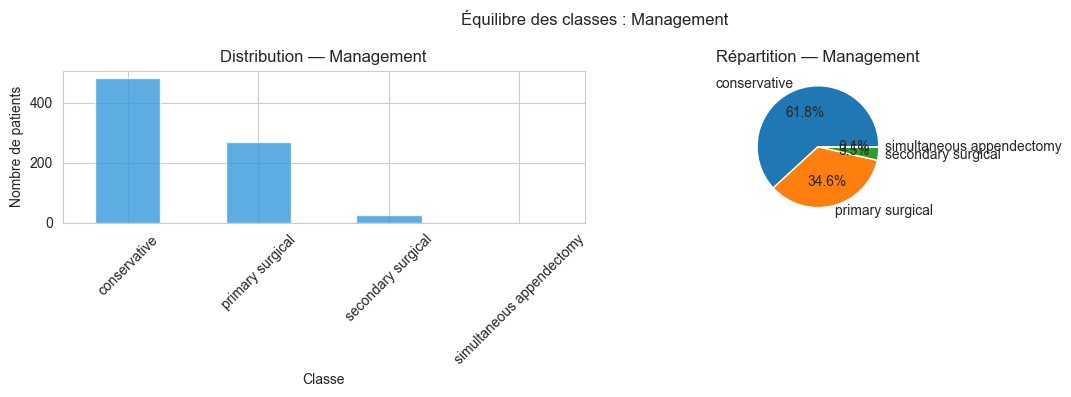

Ratio déséquilibre : 483.00
⚠️ Management : déséquilibré — privilégier ROC-AUC et F1-score

TARGET : Severity
Severity
uncomplicated    662
complicated      119
Name: count, dtype: int64

Severity
uncomplicated    84.76
complicated      15.24
Name: proportion, dtype: float64


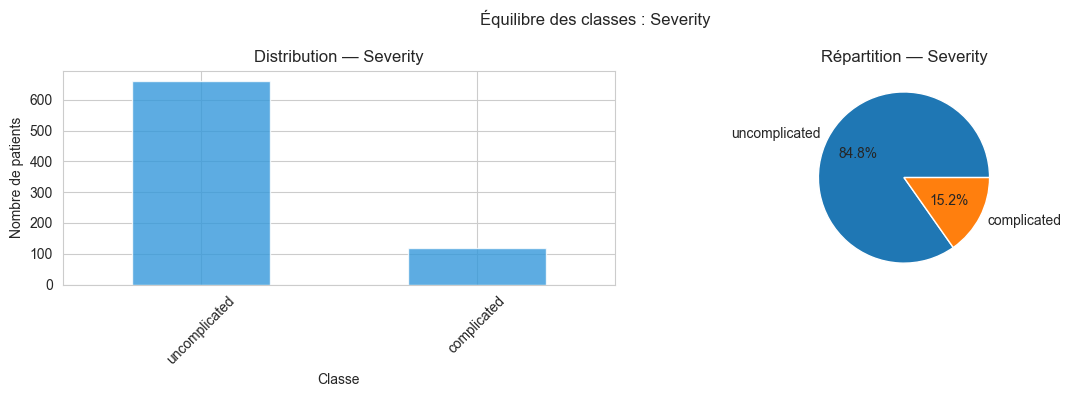

Ratio déséquilibre : 5.56
⚠️ Severity : déséquilibré — privilégier ROC-AUC et F1-score

TARGET : Diagnosis
Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64

Diagnosis
appendicitis       59.36
no appendicitis    40.64
Name: proportion, dtype: float64


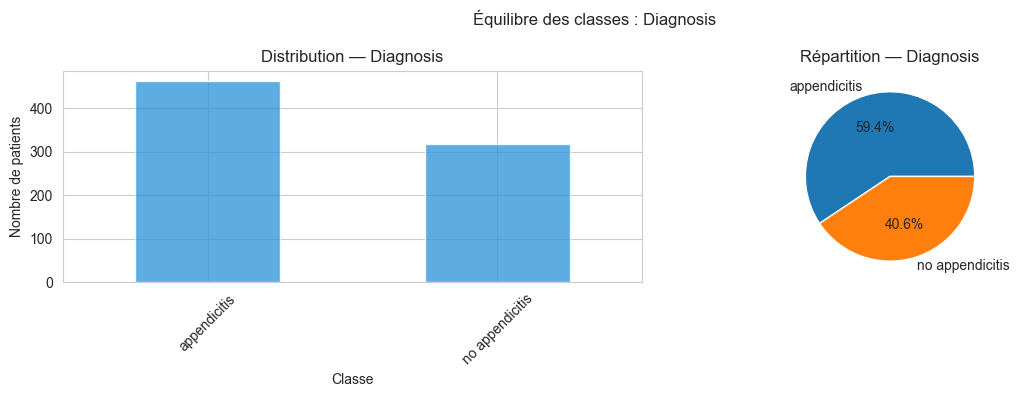

Ratio déséquilibre : 1.46
✅ Diagnosis : équilibré — métriques standard fiables



In [15]:
# ============================================================
# ANALYSE DE L'ÉQUILIBRE POUR CHAQUE TARGET
# Le dataset en vue d'analyse a 3 colonnes cibles : on les analyse toutes
# ============================================================

print('Colonnes cibles disponibles :', y.columns.tolist())
print()

for target_col in y.columns:
    print('=' * 50)
    print(f'TARGET : {target_col}')
    print('=' * 50)

    class_counts = y[target_col].value_counts()
    class_pct = y[target_col].value_counts(normalize=True) * 100

    print(class_counts)
    print()
    print(class_pct.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    class_counts.plot(kind='bar', ax=axes[0], color='#3498db', alpha=0.8)
    axes[0].set_title(f'Distribution — {target_col}')
    axes[0].set_xlabel('Classe')
    axes[0].set_ylabel('Nombre de patients')
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart
    axes[1].pie(class_counts, labels=class_counts.index,
                autopct='%1.1f%%')
    axes[1].set_title(f'Répartition — {target_col}')

    plt.suptitle(f'Équilibre des classes : {target_col}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Décision selon le ratio
    ratio = class_counts.max() / class_counts.min()
    print(f'Ratio déséquilibre : {ratio:.2f}')
    threshold=1.5 # c'est le seuil communement admis en ML pour vérifier si les classes sont équilibrées.  
    if ratio < threshold:
        print(f'✅ {target_col} : équilibré — métriques standard fiables')
    else:
        print(f'⚠️ {target_col} : déséquilibré — privilégier ROC-AUC et F1-score')
    print()


DÉCISION FINALE

Target retenue pour le modèle : Diagnosis
Raison : question médicale principale + dataset équilibré (~50/50)
         → métriques standard (accuracy, precision, recall, F1, ROC-AUC) sont fiables

Targets écartées :
  - Severity   : déséquilibré → nécessite class_weight='balanced'
  - Management : très déséquilibré (4 classes) → modèle multiclasse
                 hors de la porté du projet actuel


---
## 4. Détection et traitement des Outliers
  
Pour détecter les outliers, nous choisissons non seulement de procéder à une visualisation de la distribution de chaque variable numérique (historigramme + courbe KDE) mais aussi et surtout à la détermination du coefficient d'asymétrie, le skewness de chacune d'elle afin de choisir la méthode de traitement la plus appropriée. Cela constitue des indicateurs clé permettant d'avoir une idée des méthodes existantes dans la littérature auxquelles nous pourrons faire appel pour un traitement efficace et convenable à chaque variable. Nous optons pour une approche analytique consistant à faire parler les données.


SKEWNESS PAR VARIABLE (asymétrie)
|skewness| < 0.5  → normale   → Z-score approprié
|skewness| >= 0.5 → asymétrique → IQR approprié

Body_Temperature                 -1.475
Neutrophil_Percentage            -0.800
Height                           -0.700
Age                              -0.442
Alvarado_Score                   -0.129
Paedriatic_Appendicitis_Score     0.228
Weight                            0.528
Thrombocyte_Count                 0.715
WBC_Count                         0.766
Appendix_Diameter                 0.773
BMI                               1.170
CRP                               2.959
Length_of_Stay                    3.256
Hemoglobin                        5.646
RBC_Count                         8.416
RDW                              15.219
dtype: float64


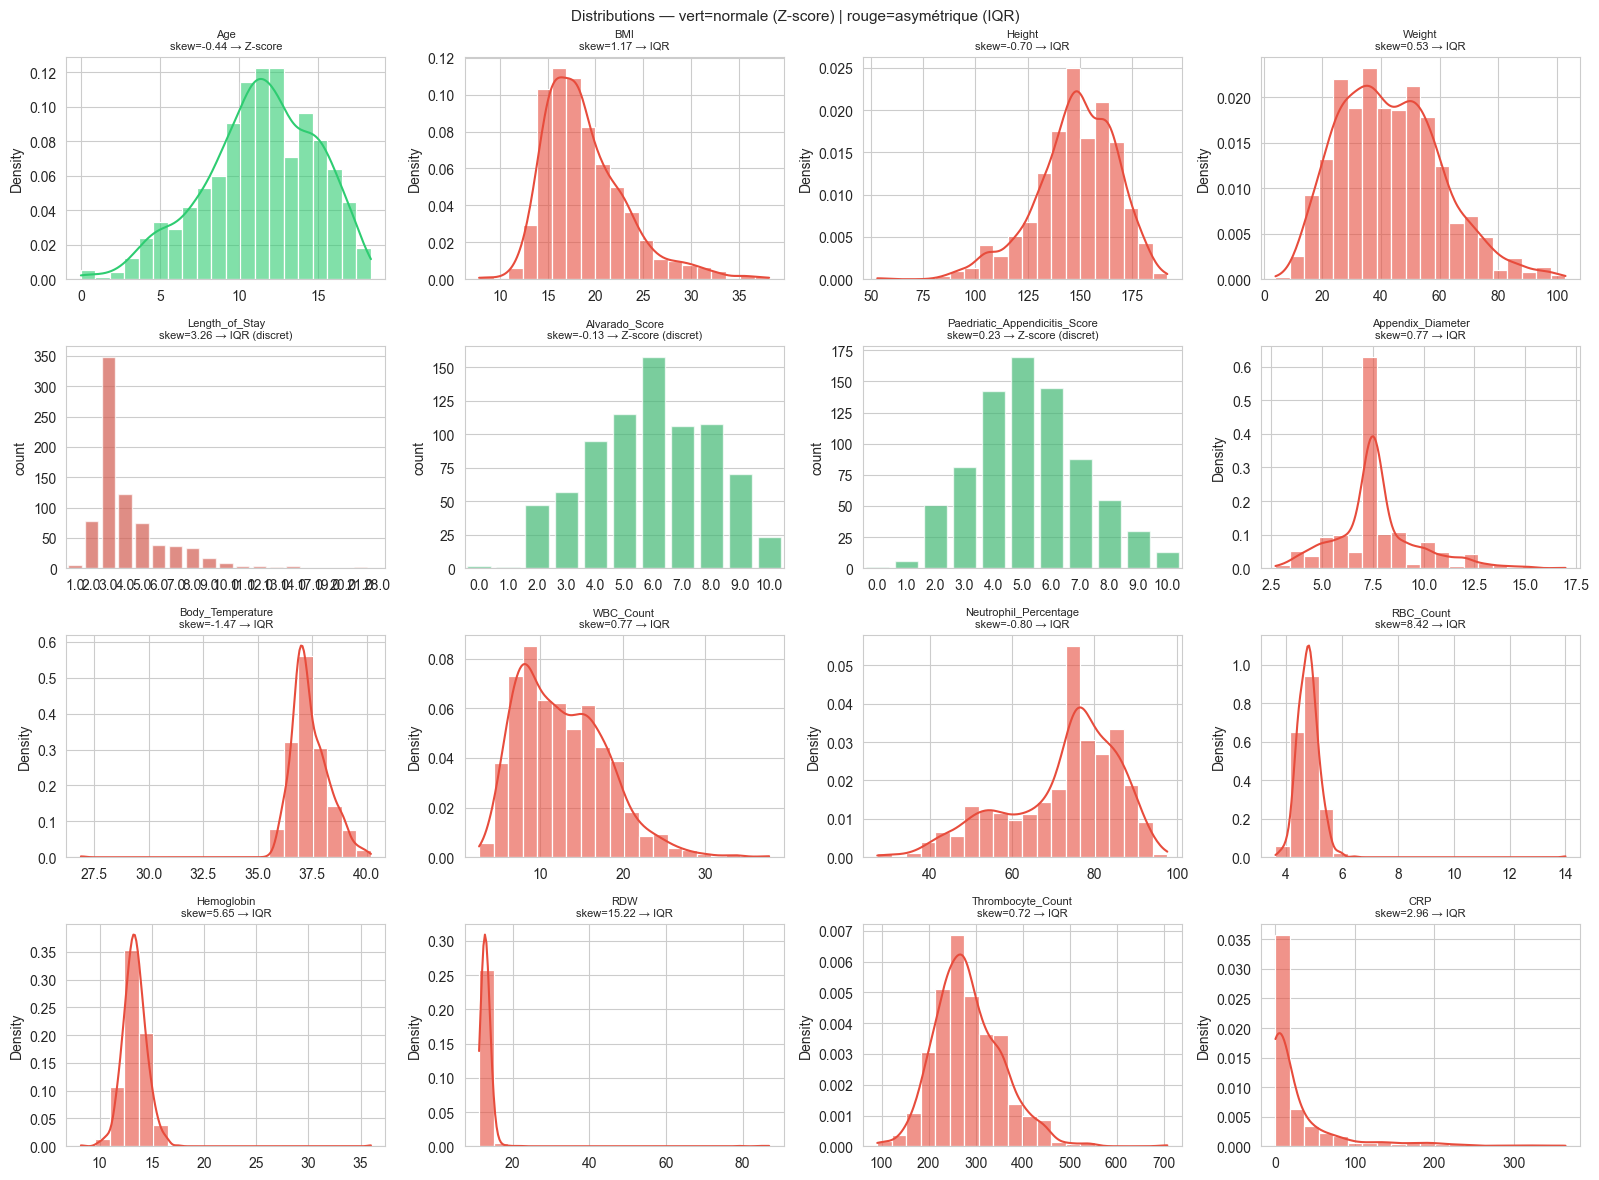

Variables normales   (3) → Z-score : ['Age', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score']
Variables asymétriques (13) → IQR    : ['BMI', 'Height', 'Weight', 'Length_of_Stay', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']


In [23]:

# ============================================================
# VISUALISATION DES DISTRIBUTIONS POUR CHOISIR LA MÉTHODE
# 
# Objectif : déterminer pour chaque variable numérique
# si sa distribution est normale (→ Z-score) 
# ou asymétrique (→ IQR)
#
# On utilise deux indicateurs :
#   - Histogramme + courbe KDE : visualisation de la forme
#   - Skewness (asymétrie)     : mesure numérique
#       |skewness| < 0.5  → distribution symétrique  → Z-score
#       |skewness| >= 0.5 → distribution asymétrique → IQR
# ============================================================

from scipy import stats

num_cols_clean = X_clean.select_dtypes(include=[np.number]).columns
n = len(num_cols_clean)

# Calcul du skewness pour chaque colonne
skewness = X_clean[num_cols_clean].skew().sort_values()

print('SKEWNESS PAR VARIABLE (asymétrie)')
print('|skewness| < 0.5  → normale   → Z-score approprié')
print('|skewness| >= 0.5 → asymétrique → IQR approprié')
print()
print(skewness.round(3))
# Visualisation des distributions pour confirmer les décisions
# sns.histplot avec kde=True ajuste automatiquement la courbe
# à l'histogramme via le paramètre bw_adjust
# bw_adjust=0.5 : moins lissé → courbe plus fidèle aux données
cols_per_row = 4
n_rows = (len(num_cols_clean) + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols_clean):
    sk = skewness[col]
    color  = '#2ecc71' if abs(sk) < 0.5 else '#e74c3c'
    method = 'Z-score' if abs(sk) < 0.5 else 'IQR'

    # Détection variable discrète :
    # si le nombre de valeurs uniques est faible (≤ 20) → discrète
    n_unique = X_clean[col].nunique()
    is_discrete = n_unique <= 20

    if is_discrete:
        # Variable discrète → barres par valeur entière, sans KDE
        sns.countplot(
            x=X_clean[col],
            color=color,
            alpha=0.7,
            ax=axes[i]
        )
        axes[i].set_title(f'{col}\nskew={sk:.2f} → {method} (discret)', fontsize=8)
    else:
        # Variable continue → histogramme + KDE ajusté
        sns.histplot(
            X_clean[col],
            bins=20,
            color=color,
            alpha=0.6,
            kde=True,
            stat='density',
            kde_kws={'bw_adjust': 0.9},
            ax=axes[i]
        )
        axes[i].set_title(f'{col}\nskew={sk:.2f} → {method}', fontsize=8)

    axes[i].set_xlabel('')

# Masquer les cases vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions — vert=normale (Z-score) | rouge=asymétrique (IQR)',
             fontsize=11)
plt.tight_layout()
plt.show()

normal_cols = [col for col in num_cols_clean
               if abs(X_clean[col].skew()) < 0.5]
skewed_cols  = [col for col in num_cols_clean
               if abs(X_clean[col].skew()) >= 0.5]

print(f'Variables normales   ({len(normal_cols)}) → Z-score : {normal_cols}')
print(f'Variables asymétriques ({len(skewed_cols)}) → IQR    : {skewed_cols}')



4.1 TRAITEMENT DES OUTLIERS — MÉTHODE ADAPTÉE PAR VARIABLE

 Suite logique de l'analyse des distributions :
   - Variables normales     (|skewness| < 0.5) → Z-score + capping
   - Variables asymétriques (|skewness| >= 0.5) → IQR + capping

Traitement choisi : Capping (Winsorization) dans les deux cas.
 On remplace les valeurs extrêmes par les bornes
au lieu de les supprimer — aucun patient n'est perdu


In [20]:


X_no_outliers = X_clean.copy()

# Compteurs pour le rapport final
total_outliers_before = 0
report = []

for col in num_cols_clean:
    sk = abs(X_no_outliers[col].skew())

    if sk < 0.5:
        # ── Z-SCORE ──────────────────────────────────────────
        # Calcul de la moyenne et de l'écart-type de la colonne
        # Une valeur est outlier si elle dépasse ±3 écarts-types
        mean = X_no_outliers[col].mean()
        std  = X_no_outliers[col].std()
        lower = mean - 3 * std
        upper = mean + 3 * std
        method = 'Z-score'

    else:
        # ── IQR ──────────────────────────────────────────────
        # Q1 = 25e percentile, Q3 = 75e percentile
        # IQR = Q3 - Q1
        # Bornes : Q1 - 1.5*IQR  et  Q3 + 1.5*IQR
        Q1    = X_no_outliers[col].quantile(0.25)
        Q3    = X_no_outliers[col].quantile(0.75)
        IQR   = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        method = 'IQR'

    # Compter les outliers AVANT capping
    n_outliers = ((X_no_outliers[col] < lower) |
                  (X_no_outliers[col] > upper)).sum()
    total_outliers_before += n_outliers

    # Capping : ramener les valeurs extrêmes aux bornes
    # clip(lower, upper) remplace :
    #   toute valeur < lower → lower
    #   toute valeur > upper → upper
    X_no_outliers[col] = X_no_outliers[col].clip(lower, upper)

    # Enregistrer dans le rapport
    if n_outliers > 0:
        report.append({
            'Variable': col,
            'Méthode': method,
            'Skewness': round(sk, 3),
            'N outliers': n_outliers,
            '% outliers': round(n_outliers / len(X_clean) * 100, 2),
            'Borne inf': round(lower, 3),
            'Borne sup': round(upper, 3)
        })


# 4.2 Rapport de traitement des outliers

In [21]:
# ============================================================
# RAPPORT DE TRAITEMENT
# ============================================================

report_df = pd.DataFrame(report).sort_values('% outliers', ascending=False)

print('RAPPORT DE TRAITEMENT DES OUTLIERS')
print('=' * 60)
display(report_df)

print(f'\nTotal outliers traités : {total_outliers_before}')
print(f'Aucun patient supprimé — forme du DataFrame : {X_no_outliers.shape}')

RAPPORT DE TRAITEMENT DES OUTLIERS


,Variable,Méthode,Skewness,N outliers,% outliers,Borne inf,Borne sup
5,Appendix_Diameter,IQR,0.773,217,27.75,5.500,9.500
13,CRP,IQR,2.959,91,11.64,-45.500,78.500
4,Length_of_Stay,IQR,3.256,44,5.63,0.000,8.000
1,BMI,IQR,1.170,30,3.84,7.990,28.830
10,Hemoglobin,IQR,5.646,26,3.32,10.750,15.950
11,RDW,IQR,15.219,23,2.94,10.800,14.800
2,Height,IQR,0.700,15,1.92,101.662,198.563
9,RBC_Count,IQR,8.416,15,1.92,3.835,5.715
6,Body_Temperature,IQR,1.475,12,1.53,35.150,39.550
12,Thrombocyte_Count,IQR,0.715,9,1.15,96.875,467.875



Total outliers traités : 505
Aucun patient supprimé — forme du DataFrame : (782, 35)



 4.3 VISUALISATION AVANT / APRÈS CAPPING
 
 On compare les boxplots pour vérifier que le traitement
 a bien réduit les valeurs extrêmes

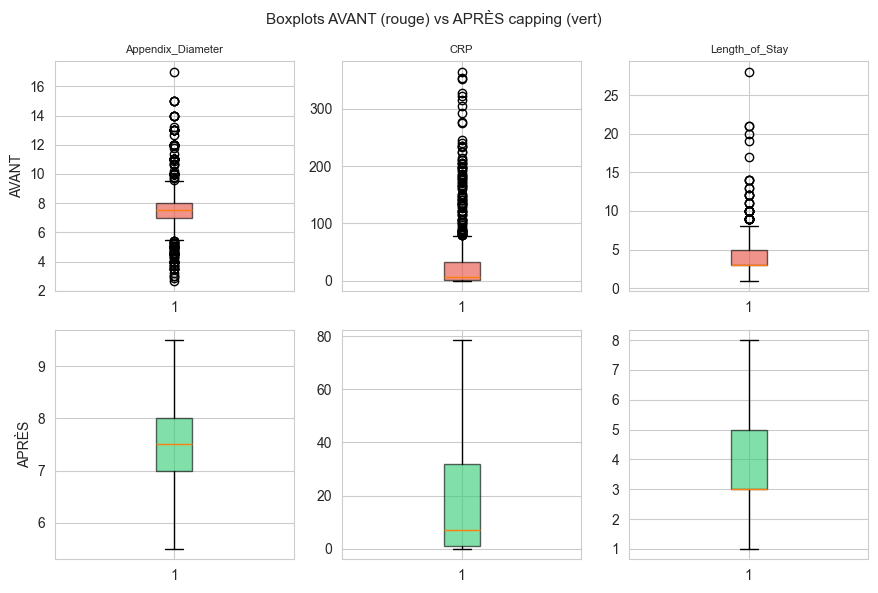

In [27]:
# Visualisation avant / après sur les 3 premières variables les plus affectées
top_cols = report_df['Variable'].tolist()[:3]

fig, axes = plt.subplots(2, len(top_cols), figsize=(len(top_cols) * 3, 6))

for i, col in enumerate(top_cols):
    axes[0, i].boxplot(X_clean[col], patch_artist=True,
                       boxprops=dict(facecolor='#e74c3c', alpha=0.6))
    axes[0, i].set_title(col, fontsize=8)
    axes[0, i].set_ylabel('AVANT' if i == 0 else '')

    axes[1, i].boxplot(X_no_outliers[col], patch_artist=True,
                       boxprops=dict(facecolor='#2ecc71', alpha=0.6))
    axes[1, i].set_ylabel('APRÈS' if i == 0 else '')

plt.suptitle('Boxplots AVANT (rouge) vs APRÈS capping (vert)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. Corrélation entre les features

**Pourquoi analyser les corrélations ?**  
Si deux features sont très corrélées (ex: r > 0.8), elles apportent la même information au modèle. Garder les deux crée de la redondance et peut nuire à certains modèles (ex: régression logistique, SVM).

**Seuil choisi : |r| > 0.8**  
Au-delà de 0.8, on considère la corrélation forte. On supprimera une des deux features.

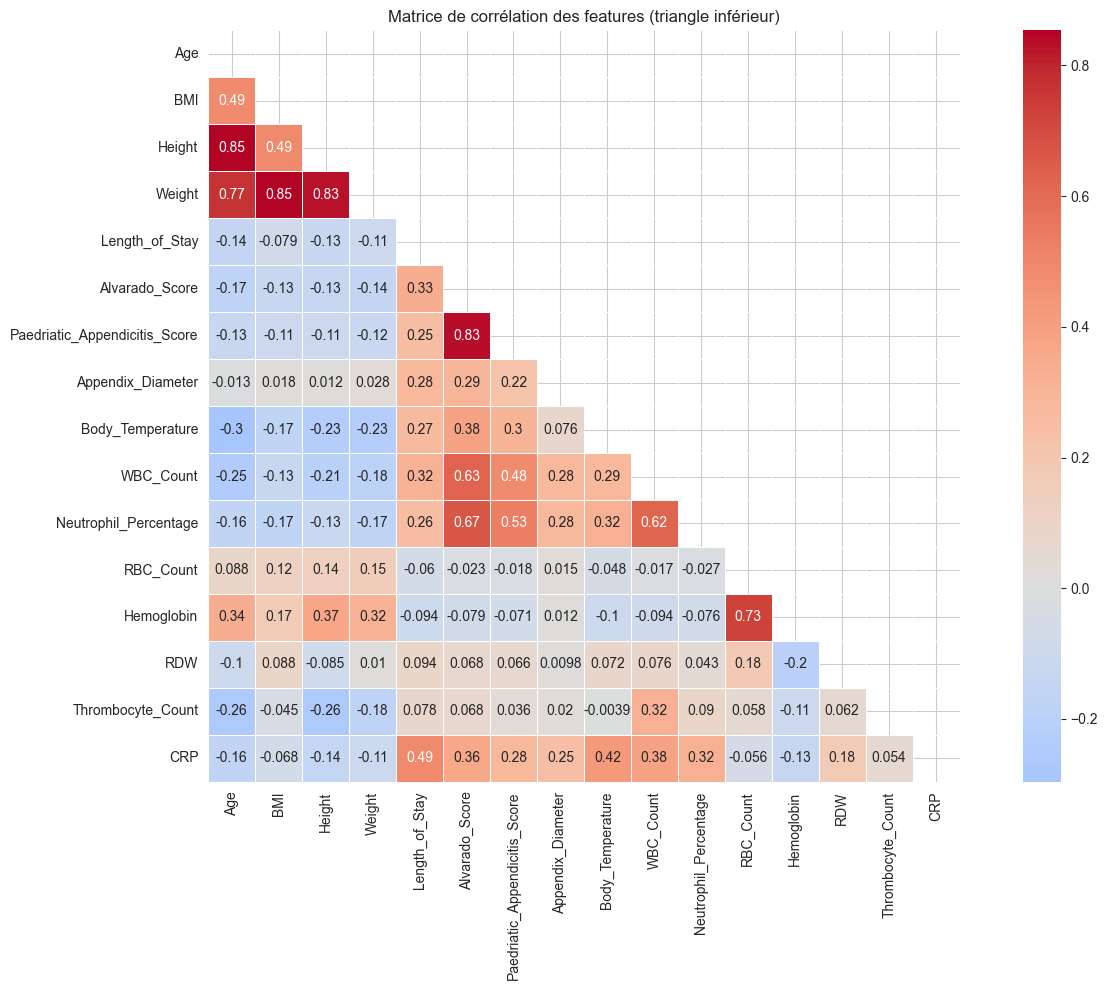

In [30]:
# corr() calcule le coefficient de Pearson entre toutes les paires de colonnes
# Valeur entre -1 (corrélation négative parfaite) et +1 (corrélation positive parfaite)
# np.triu : on masque le triangle supérieur pour éviter les doublons
corr_matrix = X_no_outliers.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True,
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation des features (triangle inférieur)')
plt.tight_layout()
plt.show()

In [29]:
# Identifier les paires fortement corrélées (|r| > 0.8)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):  # triangle inférieur uniquement
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Corrélation': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Corrélation', ascending=False)
    print(f'⚠️ {len(high_corr_df)} paires fortement corrélées (|r| > 0.8) :')
    display(high_corr_df)
else:
    print('✅ Aucune corrélation forte détectée (seuil |r| > 0.8)')

⚠️ 4 paires fortement corrélées (|r| > 0.8) :


,Feature 1,Feature 2,Corrélation
1,Weight,BMI,0.854
0,Height,Age,0.849
3,Paedriatic_Appendicitis_Score,Alvarado_Score,0.832
2,Weight,Height,0.829


In [31]:
# ============================================================
# TRAITEMENT : suppression des features redondantes
# Pour chaque paire corrélée, on supprime la deuxième feature
# (la première est conservée)
# upper : triangle supérieur de la matrice de corrélation
# any(upper[col] > 0.8) : si cette colonne est corrélée à une autre → supprimer
# ============================================================
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

X_final = X_no_outliers.drop(columns=cols_to_drop)

print(f'Features supprimées ({len(cols_to_drop)}) : {cols_to_drop}')
print(f'\nDimension avant : {X_no_outliers.shape}')
print(f'Dimension après : {X_final.shape}')

Features supprimées (3) : ['Height', 'Weight', 'Paedriatic_Appendicitis_Score']

Dimension avant : (782, 35)
Dimension après : (782, 32)


---
## 6. Optimisation mémoire

**Pourquoi optimiser la mémoire ?**  
Par défaut, pandas utilise `float64` (8 octets) et `int64` (8 octets). En passant à `float32` (4 octets) et `int32` (4 octets), on divise la mémoire par 2 sans perte de précision significative pour ce type de données médicales.

**Règle appliquée :**
- `float64` → `float32`
- `int64` → `int32`
- `object` avec < 50% valeurs uniques → `category`

In [32]:
# Mémoire AVANT optimisation
# memory_usage(deep=True) : calcule la mémoire réelle incluant les objets Python
mem_before = X_final.memory_usage(deep=True).sum() / 1024**2
print(f'Mémoire avant optimisation : {mem_before:.4f} MB')
print('\nTypes AVANT :')
print(X_final.dtypes.value_counts())

Mémoire avant optimisation : 0.8115 MB

Types AVANT :
object     19
float64    13
Name: count, dtype: int64


In [33]:
# ============================================================
# OPTIMISATION MÉMOIRE
# On parcourt chaque colonne et on réduit le type si possible
# ============================================================
X_optimized = X_final.copy()

for col in X_optimized.columns:
    col_type = X_optimized[col].dtype

    if col_type == 'float64':
        # float64 (8 octets) → float32 (4 octets)
        X_optimized[col] = X_optimized[col].astype('float32')

    elif col_type == 'int64':
        # int64 (8 octets) → int32 (4 octets)
        X_optimized[col] = X_optimized[col].astype('int32')

    elif col_type == 'object':
        # Si moins de 50% de valeurs uniques → category (plus efficace)
        n_unique = X_optimized[col].nunique()
        if n_unique / len(X_optimized) < 0.5:
            X_optimized[col] = X_optimized[col].astype('category')

# Mémoire APRÈS optimisation
mem_after = X_optimized.memory_usage(deep=True).sum() / 1024**2
reduction = ((mem_before - mem_after) / mem_before) * 100

print(f'Mémoire avant optimisation : {mem_before:.4f} MB')
print(f'Mémoire après optimisation  : {mem_after:.4f} MB')
print(f'Réduction                   : {reduction:.1f}%')
print('\nTypes APRÈS :')
print(X_optimized.dtypes.value_counts())

Mémoire avant optimisation : 0.8115 MB
Mémoire après optimisation  : 0.0576 MB
Réduction                   : 92.9%

Types APRÈS :
float32     13
category    13
category     3
category     1
category     1
category     1
Name: count, dtype: int64


---
## 7. Récapitulatif & Conclusions

In [ ]:
print('=' * 65)
print('CONCLUSIONS DE L\'EDA — DÉCISIONS PRISES')
print('=' * 65)
print(f'''
1. VALEURS MANQUANTES
   Détectées : {missing.sum()} valeurs sur {X.shape[0] * X.shape[1]} cellules
   Décision  : Imputation médiane (numériques) + mode (catégorielles)
   Résultat  : 0 valeur manquante dans X_clean ✅

2. ÉQUILIBRE DES CLASSES
   Ratio     : {ratio:.2f}
   Décision  : {"Pas de rééchantillonnage nécessaire" if ratio < 1.5 else "Appliquer class_weight=balanced"}

3. OUTLIERS
   Méthodes  : IQR (Interquartile Range) ou le Z_score
   Décision  : Capping (Winsorization) — aucun patient supprimé
   Résultat  : Valeurs extrêmes ramenées aux bornes IQR ✅

4. CORRÉLATION
   Seuil     : |r| > 0.8
   Supprimées: {cols_to_drop}
   Résultat  : {X_final.shape[1]} features conservées ✅

5. MÉMOIRE
   Avant     : {mem_before:.4f} MB
   Après     : {mem_after:.4f} MB
   Réduction : {reduction:.1f}% ✅

DATASET FINAL PRÊT POUR LE MODÈLE : X_optimized {X_optimized.shape}
''')

CONCLUSIONS DE L'EDA — DÉCISIONS PRISES

1. VALEURS MANQUANTES
   Détectées : 13980 valeurs sur 41446 cellules
   Décision  : Imputation médiane (numériques) + mode (catégorielles)
   Résultat  : 0 valeur manquante dans X_clean ✅

2. ÉQUILIBRE DES CLASSES
   Ratio     : 1.46
   Décision  : Pas de rééchantillonnage nécessaire

3. OUTLIERS
   Méthode   : IQR (Interquartile Range) ou le Z_score
   Décision  : Capping (Winsorization) — aucun patient supprimé
   Résultat  : Valeurs extrêmes ramenées aux bornes IQR ✅

4. CORRÉLATION
   Seuil     : |r| > 0.8
   Supprimées: ['Height', 'Weight', 'Paedriatic_Appendicitis_Score']
   Résultat  : 32 features conservées ✅

5. MÉMOIRE
   Avant     : 0.8115 MB
   Après     : 0.0576 MB
   Réduction : 92.9% ✅

DATASET FINAL PRÊT POUR LE MODÈLE : X_optimized (782, 32)



# 8. Sauvegarde des données

In [ ]:
# Sauvegarde des données préprocessées pour les étapes suivantes
import os

# Créer le dossier s'il n'existe pas
os.makedirs('../data/processed', exist_ok=True)

# Sauvegarder X et y préprocessés
X_optimized.to_csv('../data/processed/X_processed.csv', index=False)
y.to_csv('../data/processed/y_processed.csv', index=False)

print(f'✅ X_processed.csv sauvegardé : {X_optimized.shape}')
print(f'✅ y_processed.csv sauvegardé : {y.shape}')
print('✅ Données sauvegardées dans data/processed/')

✅ Données sauvegardées dans data/processed/
